In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

In [2]:
df = pd.read_csv("sales_data.csv")
df['Date'] = pd.to_datetime(df['Date'])

In [9]:
df

,Date,Product,Quantity,Revenue
0,2023-01-01,Chips,61,5829.42
1,2023-01-01,Biscuits,81,5174.22
2,2023-01-01,Cold Drink,92,1747.79
3,2023-01-01,Spices,84,7388.29
4,2023-01-02,Chips,33,2263.14
...,...,...,...,...
395,2023-04-09,Spices,84,7383.23
396,2023-04-10,Chips,15,1466.34
397,2023-04-10,Biscuits,60,5032.65
398,2023-04-10,Cold Drink,75,4508.15


In [3]:
daily_sales = df.groupby('Date')['Revenue'].sum().reset_index()

In [10]:
daily_sales

,Date,Revenue,Days
0,2023-01-01,20139.72,0
1,2023-01-02,16679.38,1
2,2023-01-03,8575.54,2
3,2023-01-04,12543.42,3
4,2023-01-05,11488.46,4
...,...,...,...
95,2023-04-06,10968.17,95
96,2023-04-07,9823.01,96
97,2023-04-08,7337.08,97
98,2023-04-09,16247.58,98


In [4]:
daily_sales['Days'] = (daily_sales['Date'] - daily_sales['Date'].min()).dt.days
X = daily_sales[['Days']]
y = daily_sales['Revenue']

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [7]:
y_pred = model.predict(X_test)

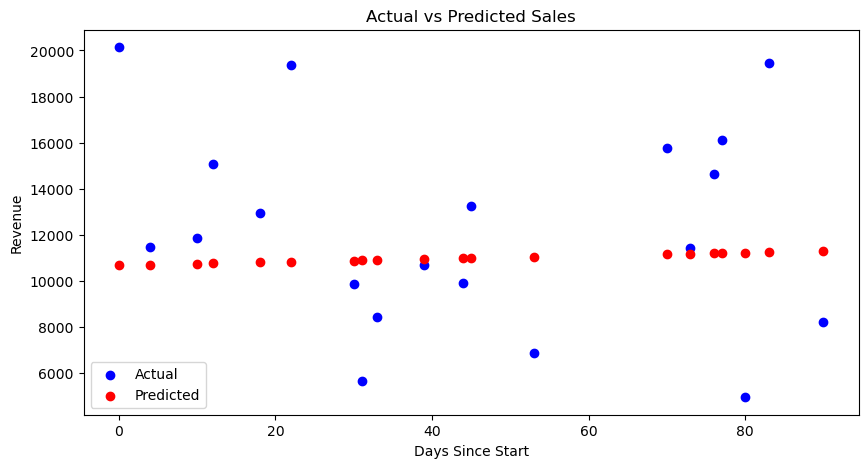

In [8]:
plt.figure(figsize=(10,5))
plt.scatter(X_test['Days'], y_test, color='blue', label='Actual')
plt.scatter(X_test['Days'], y_pred, color='red', label='Predicted')
plt.xlabel("Days Since Start")
plt.ylabel("Revenue")
plt.title("Actual vs Predicted Sales")
plt.legend()
plt.show()